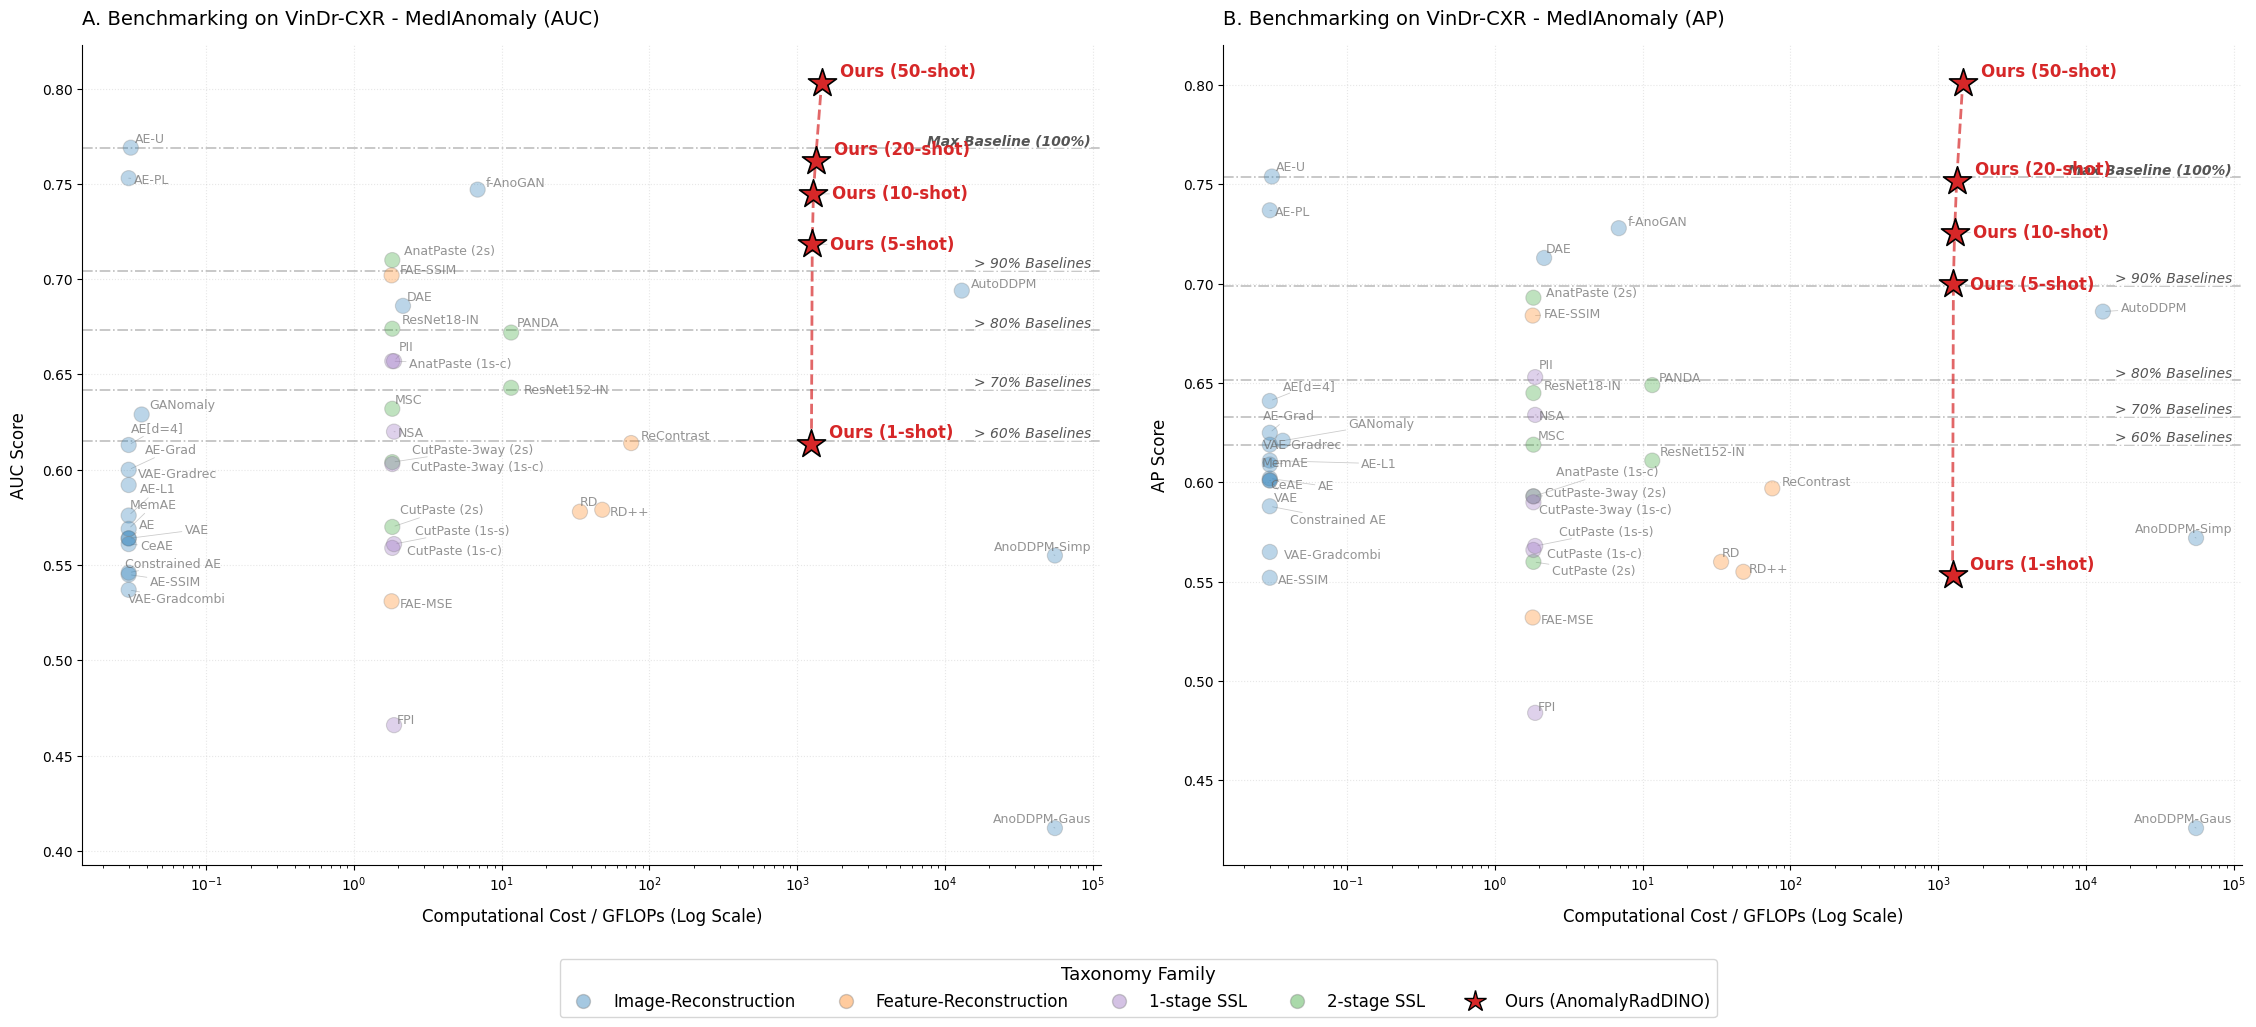

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score
from adjustText import adjust_text
from matplotlib.lines import Line2D

# ==========================================
# 1. CẤU HÌNH & LOAD BASELINES (38 Models)
# ==========================================
raw_data = [
    {"Method": "AE", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.564, "AP": 0.602},
    {"Method": "AE-L1", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.576, "AP": 0.611},
    {"Method": "AE-SSIM", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.545, "AP": 0.552},
    {"Method": "AE-PL", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.753, "AP": 0.737},
    {"Method": "AE[d=4]", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.613, "AP": 0.641},
    {"Method": "VAE", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.564, "AP": 0.601},
    {"Method": "Constrained AE", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.546, "AP": 0.588},
    {"Method": "MemAE", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.569, "AP": 0.609},
    {"Method": "CeAE", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.561, "AP": 0.601},
    {"Method": "AnoDDPM-Gaus", "Family": "Image-Reconstruction", "FLOPs": 55600.0, "AUC": 0.412, "AP": 0.426},
    {"Method": "AnoDDPM-Simp", "Family": "Image-Reconstruction", "FLOPs": 55600.0, "AUC": 0.555, "AP": 0.572},
    {"Method": "AutoDDPM", "Family": "Image-Reconstruction", "FLOPs": 13020.0, "AUC": 0.694, "AP": 0.686},
    {"Method": "f-AnoGAN", "Family": "Image-Reconstruction", "FLOPs": 6.88, "AUC": 0.747, "AP": 0.728},
    {"Method": "GANomaly", "Family": "Image-Reconstruction", "FLOPs": 0.0366, "AUC": 0.629, "AP": 0.621},
    {"Method": "AE-U", "Family": "Image-Reconstruction", "FLOPs": 0.0309, "AUC": 0.769, "AP": 0.754},
    {"Method": "DAE", "Family": "Image-Reconstruction", "FLOPs": 2.15, "AUC": 0.686, "AP": 0.713},
    {"Method": "AE-Grad", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.600, "AP": 0.625},
    {"Method": "VAE-Gradrec", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.592, "AP": 0.619},
    {"Method": "VAE-Gradcombi", "Family": "Image-Reconstruction", "FLOPs": 0.0299, "AUC": 0.537, "AP": 0.565},
    {"Method": "FAE-SSIM", "Family": "Feature-Reconstruction", "FLOPs": 1.80, "AUC": 0.702, "AP": 0.684},
    {"Method": "FAE-MSE", "Family": "Feature-Reconstruction", "FLOPs": 1.80, "AUC": 0.531, "AP": 0.532},
    {"Method": "RD", "Family": "Feature-Reconstruction", "FLOPs": 33.9, "AUC": 0.578, "AP": 0.560},
    {"Method": "RD++", "Family": "Feature-Reconstruction", "FLOPs": 48.0, "AUC": 0.579, "AP": 0.555},
    {"Method": "ReContrast", "Family": "Feature-Reconstruction", "FLOPs": 75.3, "AUC": 0.614, "AP": 0.597},
    {"Method": "ResNet18-IN", "Family": "2-stage SSL", "FLOPs": 1.82, "AUC": 0.674, "AP": 0.645},
    {"Method": "ResNet152-IN", "Family": "2-stage SSL", "FLOPs": 11.6, "AUC": 0.643, "AP": 0.611},
    {"Method": "PANDA", "Family": "2-stage SSL", "FLOPs": 11.6, "AUC": 0.672, "AP": 0.649},
    {"Method": "MSC", "Family": "2-stage SSL", "FLOPs": 1.82, "AUC": 0.632, "AP": 0.619},
    {"Method": "CutPaste (2s)", "Family": "2-stage SSL", "FLOPs": 1.82, "AUC": 0.570, "AP": 0.560},
    {"Method": "CutPaste-3way (2s)", "Family": "2-stage SSL", "FLOPs": 1.82, "AUC": 0.604, "AP": 0.593},
    {"Method": "AnatPaste (2s)", "Family": "2-stage SSL", "FLOPs": 1.82, "AUC": 0.710, "AP": 0.693},
    {"Method": "CutPaste (1s-c)", "Family": "1-stage SSL", "FLOPs": 1.82, "AUC": 0.559, "AP": 0.566},
    {"Method": "CutPaste-3way (1s-c)", "Family": "1-stage SSL", "FLOPs": 1.82, "AUC": 0.603, "AP": 0.590},
    {"Method": "AnatPaste (1s-c)", "Family": "1-stage SSL", "FLOPs": 1.82, "AUC": 0.657, "AP": 0.593},
    {"Method": "CutPaste (1s-s)", "Family": "1-stage SSL", "FLOPs": 1.87, "AUC": 0.561, "AP": 0.568},
    {"Method": "FPI", "Family": "1-stage SSL", "FLOPs": 1.87, "AUC": 0.466, "AP": 0.484},
    {"Method": "PII", "Family": "1-stage SSL", "FLOPs": 1.87, "AUC": 0.657, "AP": 0.653},
    {"Method": "NSA", "Family": "1-stage SSL", "FLOPs": 1.87, "AUC": 0.620, "AP": 0.634},
]
df_baselines = pd.DataFrame(raw_data)

# ==========================================
# 2. DATA EXTRACTION: OURS (AnomalyRadDINOv2 - AAMB)
# ==========================================
ROOT_DIR = '/home/ca_uop_muoi/Applications/graduate_thesis/notebook/anomaly_detection/benchmarking/medianomaly/vindrcxr'
target_cases = {'8': 1, '9': 5, '10': 10, '11': 20, '1': 50}
data_versions = ['v1', 'v2', 'v3', 'v4', 'v5']   
model_name = 'aamb'            
fixed_key = "k_1_top10_percent"

flops_mapping_v2 = {
    1: 1250.57, 5: 1266.32, 10: 1289.69, 20: 1332.97, 50: 1464.63
}

records = []
for dv in data_versions:
    for cid, N in target_cases.items():
        path = os.path.join(ROOT_DIR, dv, model_name, f'inference_case_{cid}.npz')
        if os.path.exists(path):
            data = np.load(path)
            if fixed_key in data:
                y_true = data['true_labels']
                y_score = data[fixed_key]
                records.append({
                    "N": N, "Data_Version": dv,
                    "AUC": roc_auc_score(y_true, y_score),
                    "AP": average_precision_score(y_true, y_score)
                })

df_v2_raw = pd.DataFrame(records)

if not df_v2_raw.empty:
    df_v2_agg = df_v2_raw.groupby('N', as_index=False)[['AUC', 'AP']].mean()
    df_v2_agg['Method'] = df_v2_agg['N'].apply(lambda x: f"Ours ({int(x)}-shot)")
    df_v2_agg['Family'] = "Ours"
    df_v2_agg['FLOPs'] = df_v2_agg['N'].map(flops_mapping_v2)
else:
    df_v2_agg = pd.DataFrame(columns=['N', 'AUC', 'AP', 'Method', 'Family', 'FLOPs'])
    
# ==========================================
# 3. SETUPS TẠO BIỂU ĐỒ & ABLATION SURPASSED LINES
# ==========================================
plt.rcParams.update({
    'font.family': 'sans-serif', 'axes.titlesize': 14, 'axes.titleweight': 'normal',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12
})

palette = {
    "Image-Reconstruction": "#1f77b4", "Feature-Reconstruction": "#ff7f0e",  
    "1-stage SSL": "#9467bd", "2-stage SSL": "#2ca02c", "Ours": "#d62728"                     
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

def draw_scatter_chart(ax, metric, title_letter):
    # 1. Vẽ phân tán cho các Baselines (làm mờ, marker hình tròn)
    sns.scatterplot(
        data=df_baselines, x="FLOPs", y=metric, hue="Family",
        s=120, alpha=0.3, palette=palette, 
        edgecolor="gray", linewidth=0.8, ax=ax, legend=False, marker='o', zorder=2
    )
    
    # 2. Vẽ phân tán cho "Ours" (làm nổi bật, marker hình ngôi sao, viền rõ)
    if not df_v2_agg.empty:
        sns.scatterplot(
            data=df_v2_agg, x="FLOPs", y=metric, color="#d62728",
            s=450, alpha=1.0, edgecolor="black", linewidth=1.2, 
            ax=ax, legend=False, marker='*', zorder=4
        )
        # Đường line nối các N-shots
        ax.plot(df_v2_agg['FLOPs'], df_v2_agg[metric], color='#d62728', linestyle='--', linewidth=2.0, alpha=0.7, zorder=3)
        
    # ----------------------------------------------------
    # VẼ PERCENTILES CHO BASELINES (60%, 70%, 80%, 90%, 100%)
    # ----------------------------------------------------
    percentiles = [60, 70, 80, 90, 100]
    baseline_metrics = df_baselines[metric].values
    
    # Tính giá trị tại các mốc % baselines
    p_values = np.percentile(baseline_metrics, percentiles)
    
    for p, val in zip(percentiles, p_values):
        # Kẻ đường vạch ngang đứt nét mờ
        ax.axhline(val, color='gray', linestyle='-.', lw=1.2, alpha=0.5, zorder=1)
        
        # Thêm text chú thích gọn gàng, đặt sát viền bên phải của TỪNG subplot 
        # (tránh việc chữ văng ra ngoài gây đè lên biểu đồ kế bên)
        label_text = f"Max Baseline (100%)" if p == 100 else f"> {p}% Baselines"
        
        ax.text(
            0.99, val, label_text,
            color='#555555', va='bottom', ha='right', fontsize=10, fontstyle='italic', weight='bold' if p == 100 else 'normal',
            transform=ax.get_yaxis_transform(), clip_on=False,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.2)
        )

    ax.set_xscale('log')
    ax.set_title(f'{title_letter}. Benchmarking on VinDr-CXR - MedIAnomaly ({metric})', pad=15)
    ax.set_xlabel('Computational Cost / GFLOPs (Log Scale)', labelpad=10)
    ax.set_ylabel(f'{metric} Score', labelpad=10)
    
    # ----------------------------------------------------
    # VẼ TEXT (Label Các model) - Làm mờ chữ baselines
    # ----------------------------------------------------
    texts = []
    # Texts cho Baselines
    for _, row in df_baselines.iterrows():
        texts.append(ax.text(row['FLOPs'], row[metric], row['Method'], color='#666666', fontsize=9, alpha=0.7))
        
    # Texts cho Ours
    if not df_v2_agg.empty:
        for _, row in df_v2_agg.iterrows():
            texts.append(ax.text(row['FLOPs'], row[metric], row['Method'], color='#d62728', weight='bold', fontsize=12))

    # Tự động tối ưu xếp chữ
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color='gray', lw=0.6, alpha=0.4))
    ax.grid(True, ls=':', alpha=0.3)

draw_scatter_chart(ax1, metric="AUC", title_letter="A")
draw_scatter_chart(ax2, metric="AP", title_letter="B")

# ==========================================
# 4. TẠO LEGEND TỔNG
# ==========================================
custom_lines = []
# Legend cho Baselines (chấm tròn, mờ)
for family, color in palette.items():
    if family != "Ours":
        custom_lines.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, markeredgecolor='gray', alpha=0.4, lw=0))

# Legend cho Ours (ngôi sao, rõ, bọc viền)
custom_lines.append(Line2D([0], [0], marker='*', color='w', markerfacecolor=palette["Ours"], markersize=16, markeredgecolor='black', alpha=1.0, lw=0))

# Re-order keys cho legend
legend_keys = [k for k in palette.keys() if k != "Ours"] + ["Ours (AnomalyRadDINO)"]

fig.legend(
    custom_lines, legend_keys, loc='lower center', 
    bbox_to_anchor=(0.5, -0.06), ncol=5, fontsize=12, 
    title="Taxonomy Family", title_fontsize=13, frameon=True, edgecolor='#cccccc'
)

# Cân chỉnh không gian tổng thể gọn gàng
plt.subplots_adjust(top=0.92, bottom=0.1, left=0.06, right=0.96, wspace=0.12)
plt.show()

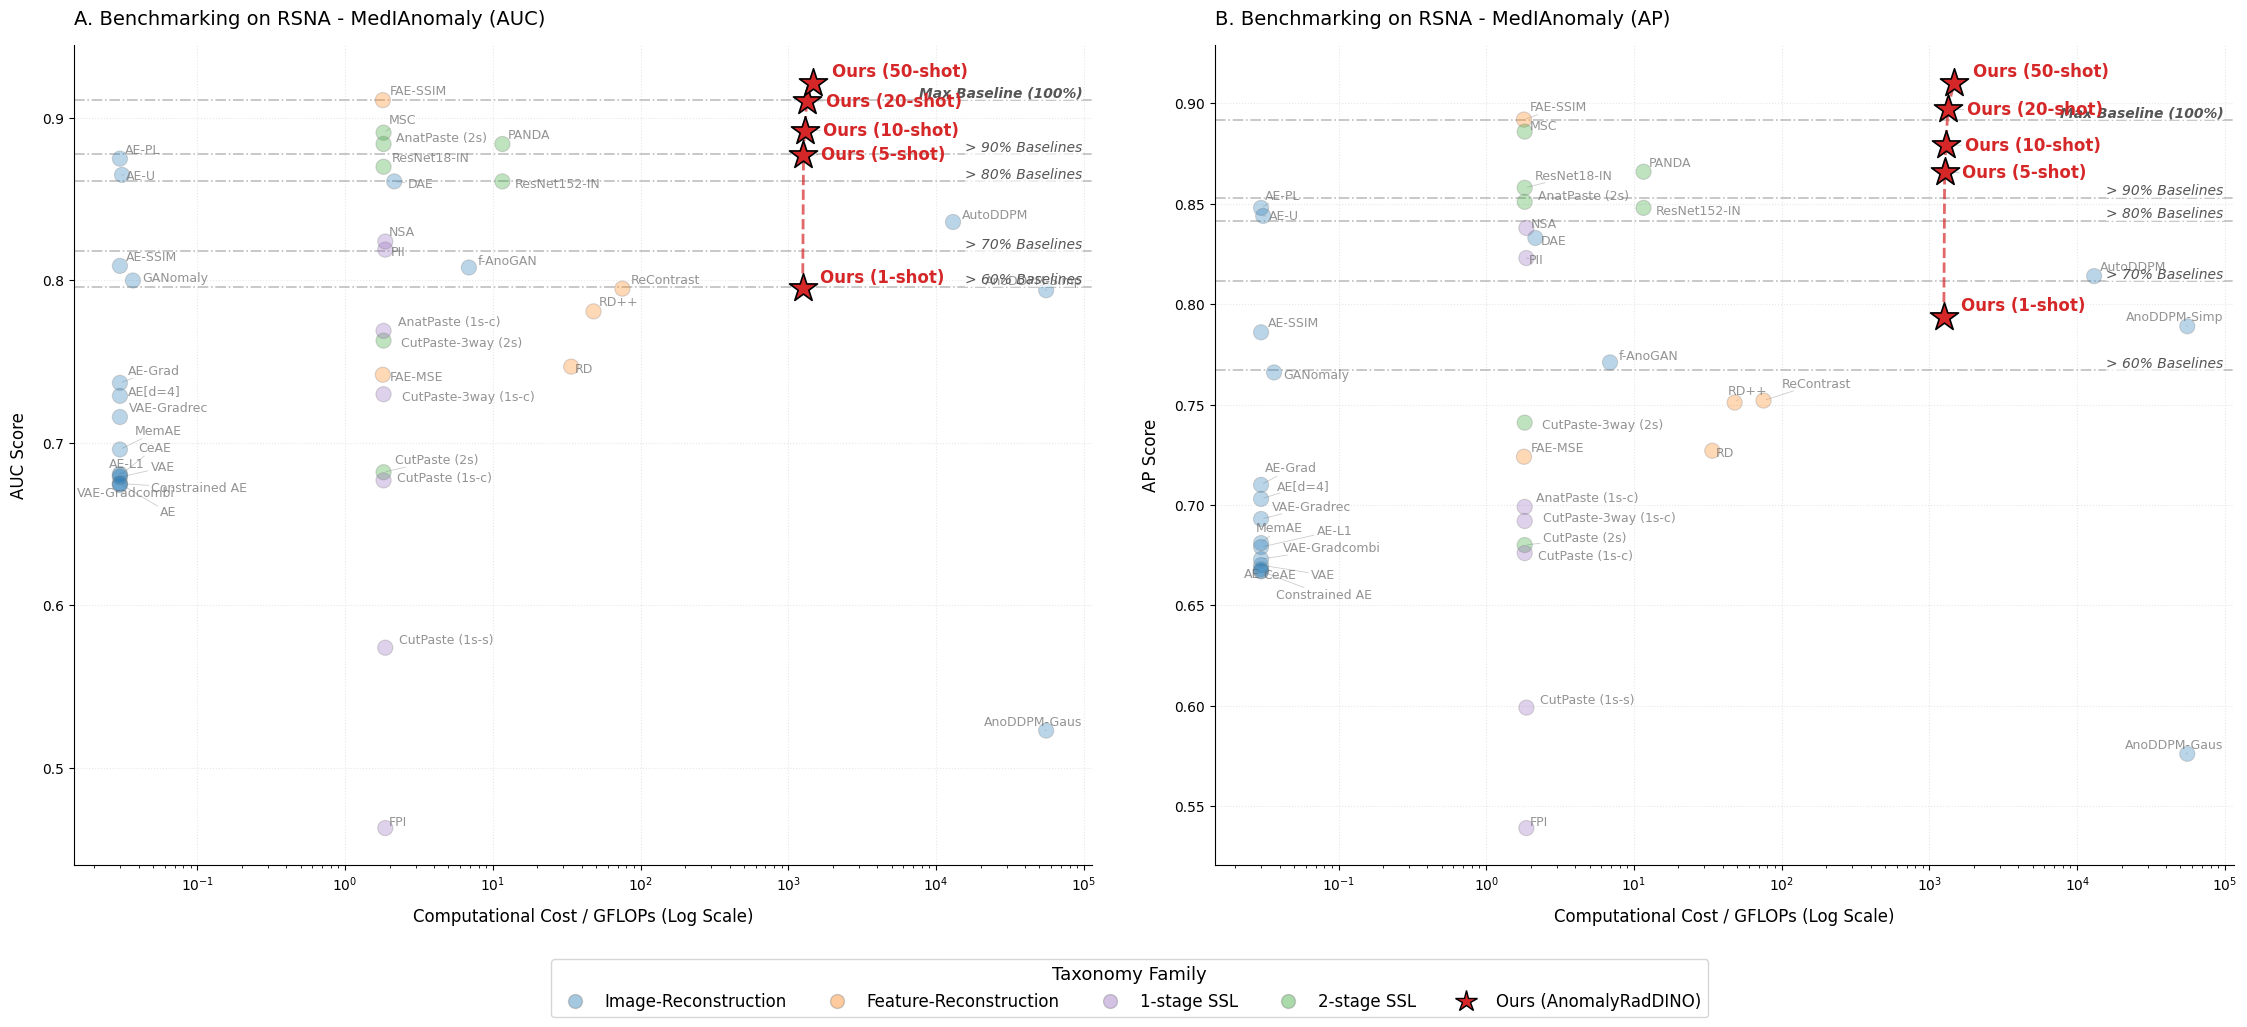

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score
from adjustText import adjust_text
from matplotlib.lines import Line2D

# ==========================================
# 1. CẤU HÌNH & LOAD BASELINES (38 Models)
# ==========================================
raw_data = [
    # --- Image-Reconstruction ---
    {"Method": "AE", "Family": "Image-Reconstruction", "Params": 2.35, "FLOPs": 0.0299, "AUC": 0.675, "AP": 0.667},
    {"Method": "AE-L1", "Family": "Image-Reconstruction", "Params": 2.35, "FLOPs": 0.0299, "AUC": 0.681, "AP": 0.679},
    {"Method": "AE-SSIM", "Family": "Image-Reconstruction", "Params": 2.35, "FLOPs": 0.0299, "AUC": 0.809, "AP": 0.786},
    {"Method": "AE-PL", "Family": "Image-Reconstruction", "Params": 2.35, "FLOPs": 0.0299, "AUC": 0.875, "AP": 0.848},
    {"Method": "AE[d=4]", "Family": "Image-Reconstruction", "Params": 2.33, "FLOPs": 0.0299, "AUC": 0.729, "AP": 0.703},
    {"Method": "VAE", "Family": "Image-Reconstruction", "Params": 2.37, "FLOPs": 0.0299, "AUC": 0.679, "AP": 0.670},
    {"Method": "Constrained AE", "Family": "Image-Reconstruction", "Params": 2.35, "FLOPs": 0.0299, "AUC": 0.675, "AP": 0.667},
    {"Method": "MemAE", "Family": "Image-Reconstruction", "Params": 2.35, "FLOPs": 0.0299, "AUC": 0.696, "AP": 0.681},
    {"Method": "CeAE", "Family": "Image-Reconstruction", "Params": 2.35, "FLOPs": 0.0299, "AUC": 0.680, "AP": 0.668},
    {"Method": "AnoDDPM-Gaus", "Family": "Image-Reconstruction", "Params": 132.0, "FLOPs": 55600.0, "AUC": 0.523, "AP": 0.576},
    {"Method": "AnoDDPM-Simp", "Family": "Image-Reconstruction", "Params": 132.0, "FLOPs": 55600.0, "AUC": 0.794, "AP": 0.789},
    {"Method": "AutoDDPM", "Family": "Image-Reconstruction", "Params": 18.0, "FLOPs": 13020.0, "AUC": 0.836, "AP": 0.814},
    {"Method": "f-AnoGAN", "Family": "Image-Reconstruction", "Params": 28.5, "FLOPs": 6.88, "AUC": 0.808, "AP": 0.771},
    {"Method": "GANomaly", "Family": "Image-Reconstruction", "Params": 3.52, "FLOPs": 0.0366, "AUC": 0.800, "AP": 0.766},
    {"Method": "AE-U", "Family": "Image-Reconstruction", "Params": 2.35, "FLOPs": 0.0309, "AUC": 0.865, "AP": 0.844},
    {"Method": "DAE", "Family": "Image-Reconstruction", "Params": 2.79, "FLOPs": 2.15, "AUC": 0.861, "AP": 0.833},
    {"Method": "AE-Grad", "Family": "Image-Reconstruction", "Params": 2.35, "FLOPs": 0.0299, "AUC": 0.737, "AP": 0.710},
    {"Method": "VAE-Gradrec", "Family": "Image-Reconstruction", "Params": 2.37, "FLOPs": 0.0299, "AUC": 0.716, "AP": 0.693},
    {"Method": "VAE-Gradcombi", "Family": "Image-Reconstruction", "Params": 2.37, "FLOPs": 0.0299, "AUC": 0.674, "AP": 0.673},

    # --- Feature-Reconstruction ---
    {"Method": "FAE-SSIM", "Family": "Feature-Reconstruction", "Params": 11.0, "FLOPs": 1.80, "AUC": 0.911, "AP": 0.892},
    {"Method": "FAE-MSE", "Family": "Feature-Reconstruction", "Params": 11.0, "FLOPs": 1.80, "AUC": 0.742, "AP": 0.724},
    {"Method": "RD", "Family": "Feature-Reconstruction", "Params": 80.6, "FLOPs": 33.9, "AUC": 0.747, "AP": 0.727},
    {"Method": "RD++", "Family": "Feature-Reconstruction", "Params": 166.0, "FLOPs": 48.0, "AUC": 0.781, "AP": 0.751},
    {"Method": "ReContrast", "Family": "Feature-Reconstruction", "Params": 136.0, "FLOPs": 75.3, "AUC": 0.795, "AP": 0.752},

    # --- 2-stage SSL ---
    {"Method": "ResNet18-IN", "Family": "2-stage SSL", "Params": 11.18, "FLOPs": 1.82, "AUC": 0.870, "AP": 0.858},
    {"Method": "ResNet152-IN", "Family": "2-stage SSL", "Params": 58.14, "FLOPs": 11.6, "AUC": 0.861, "AP": 0.848},
    {"Method": "PANDA", "Family": "2-stage SSL", "Params": 58.14, "FLOPs": 11.6, "AUC": 0.884, "AP": 0.866},
    {"Method": "MSC", "Family": "2-stage SSL", "Params": 11.18, "FLOPs": 1.82, "AUC": 0.891, "AP": 0.886},
    {"Method": "CutPaste (2s)", "Family": "2-stage SSL", "Params": 11.18, "FLOPs": 1.82, "AUC": 0.682, "AP": 0.680},
    {"Method": "CutPaste-3way (2s)", "Family": "2-stage SSL", "Params": 11.18, "FLOPs": 1.82, "AUC": 0.763, "AP": 0.741},
    {"Method": "AnatPaste (2s)", "Family": "2-stage SSL", "Params": 11.18, "FLOPs": 1.82, "AUC": 0.884, "AP": 0.851},

    # --- 1-stage SSL ---
    {"Method": "CutPaste (1s-c)", "Family": "1-stage SSL", "Params": 11.51, "FLOPs": 1.82, "AUC": 0.677, "AP": 0.676},
    {"Method": "CutPaste-3way (1s-c)", "Family": "1-stage SSL", "Params": 11.51, "FLOPs": 1.82, "AUC": 0.730, "AP": 0.692},
    {"Method": "AnatPaste (1s-c)", "Family": "1-stage SSL", "Params": 11.51, "FLOPs": 1.82, "AUC": 0.769, "AP": 0.699},
    {"Method": "CutPaste (1s-s)", "Family": "1-stage SSL", "Params": 11.49, "FLOPs": 1.87, "AUC": 0.574, "AP": 0.599},
    {"Method": "FPI", "Family": "1-stage SSL", "Params": 11.49, "FLOPs": 1.87, "AUC": 0.463, "AP": 0.539},
    {"Method": "PII", "Family": "1-stage SSL", "Params": 11.49, "FLOPs": 1.87, "AUC": 0.819, "AP": 0.823},
    {"Method": "NSA", "Family": "1-stage SSL", "Params": 11.49, "FLOPs": 1.87, "AUC": 0.824, "AP": 0.838},]
df_baselines = pd.DataFrame(raw_data)

# ==========================================
# 2. DATA EXTRACTION: OURS (AnomalyRadDINOv2 - AAMB)
# ==========================================
ROOT_DIR = '/home/ca_uop_muoi/Applications/graduate_thesis/notebook/anomaly_detection/benchmarking/medianomaly/rsna'
target_cases = {'8': 1, '9': 5, '10': 10, '11': 20, '1': 50}
data_versions = ['v1', 'v2', 'v3', 'v4', 'v5']   
model_name = 'aamb'            
fixed_key = "k_1_top10_percent"

flops_mapping_v2 = {
    1: 1250.57, 5: 1266.32, 10: 1289.69, 20: 1332.97, 50: 1464.63
}

records = []
for dv in data_versions:
    for cid, N in target_cases.items():
        path = os.path.join(ROOT_DIR, dv, model_name, f'inference_case_{cid}.npz')
        if os.path.exists(path):
            data = np.load(path)
            if fixed_key in data:
                y_true = data['true_labels']
                y_score = data[fixed_key]
                records.append({
                    "N": N, "Data_Version": dv,
                    "AUC": roc_auc_score(y_true, y_score),
                    "AP": average_precision_score(y_true, y_score)
                })

df_v2_raw = pd.DataFrame(records)

if not df_v2_raw.empty:
    df_v2_agg = df_v2_raw.groupby('N', as_index=False)[['AUC', 'AP']].mean()
    df_v2_agg['Method'] = df_v2_agg['N'].apply(lambda x: f"Ours ({int(x)}-shot)")
    df_v2_agg['Family'] = "Ours"
    df_v2_agg['FLOPs'] = df_v2_agg['N'].map(flops_mapping_v2)
else:
    df_v2_agg = pd.DataFrame(columns=['N', 'AUC', 'AP', 'Method', 'Family', 'FLOPs'])
    
# ==========================================
# 3. SETUPS TẠO BIỂU ĐỒ & ABLATION SURPASSED LINES
# ==========================================
plt.rcParams.update({
    'font.family': 'sans-serif', 'axes.titlesize': 14, 'axes.titleweight': 'normal',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12
})

palette = {
    "Image-Reconstruction": "#1f77b4", "Feature-Reconstruction": "#ff7f0e",  
    "1-stage SSL": "#9467bd", "2-stage SSL": "#2ca02c", "Ours": "#d62728"                     
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

def draw_scatter_chart(ax, metric, title_letter):
    # 1. Vẽ phân tán cho các Baselines (làm mờ, marker hình tròn)
    sns.scatterplot(
        data=df_baselines, x="FLOPs", y=metric, hue="Family",
        s=120, alpha=0.3, palette=palette, 
        edgecolor="gray", linewidth=0.8, ax=ax, legend=False, marker='o', zorder=2
    )
    
    # 2. Vẽ phân tán cho "Ours" (làm nổi bật, marker hình ngôi sao, viền rõ)
    if not df_v2_agg.empty:
        sns.scatterplot(
            data=df_v2_agg, x="FLOPs", y=metric, color="#d62728",
            s=450, alpha=1.0, edgecolor="black", linewidth=1.2, 
            ax=ax, legend=False, marker='*', zorder=4
        )
        # Đường line nối các N-shots
        ax.plot(df_v2_agg['FLOPs'], df_v2_agg[metric], color='#d62728', linestyle='--', linewidth=2.0, alpha=0.7, zorder=3)
        
    # ----------------------------------------------------
    # VẼ PERCENTILES CHO BASELINES (60%, 70%, 80%, 90%, 100%)
    # ----------------------------------------------------
    percentiles = [60, 70, 80, 90, 100]
    baseline_metrics = df_baselines[metric].values
    
    # Tính giá trị tại các mốc % baselines
    p_values = np.percentile(baseline_metrics, percentiles)
    
    for p, val in zip(percentiles, p_values):
        # Kẻ đường vạch ngang đứt nét mờ
        ax.axhline(val, color='gray', linestyle='-.', lw=1.2, alpha=0.5, zorder=1)
        
        # Thêm text chú thích gọn gàng, đặt sát viền bên phải của TỪNG subplot 
        # (tránh việc chữ văng ra ngoài gây đè lên biểu đồ kế bên)
        label_text = f"Max Baseline (100%)" if p == 100 else f"> {p}% Baselines"
        
        ax.text(
            0.99, val, label_text,
            color='#555555', va='bottom', ha='right', fontsize=10, fontstyle='italic', weight='bold' if p == 100 else 'normal',
            transform=ax.get_yaxis_transform(), clip_on=False,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.2)
        )

    ax.set_xscale('log')
    ax.set_title(f'{title_letter}. Benchmarking on RSNA - MedIAnomaly ({metric})', pad=15)
    ax.set_xlabel('Computational Cost / GFLOPs (Log Scale)', labelpad=10)
    ax.set_ylabel(f'{metric} Score', labelpad=10)
    
    # ----------------------------------------------------
    # VẼ TEXT (Label Các model) - Làm mờ chữ baselines
    # ----------------------------------------------------
    texts = []
    # Texts cho Baselines
    for _, row in df_baselines.iterrows():
        texts.append(ax.text(row['FLOPs'], row[metric], row['Method'], color='#666666', fontsize=9, alpha=0.7))
        
    # Texts cho Ours
    if not df_v2_agg.empty:
        for _, row in df_v2_agg.iterrows():
            texts.append(ax.text(row['FLOPs'], row[metric], row['Method'], color='#d62728', weight='bold', fontsize=12))

    # Tự động tối ưu xếp chữ
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color='gray', lw=0.6, alpha=0.4))
    ax.grid(True, ls=':', alpha=0.3)

draw_scatter_chart(ax1, metric="AUC", title_letter="A")
draw_scatter_chart(ax2, metric="AP", title_letter="B")

# ==========================================
# 4. TẠO LEGEND TỔNG
# ==========================================
custom_lines = []
# Legend cho Baselines (chấm tròn, mờ)
for family, color in palette.items():
    if family != "Ours":
        custom_lines.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, markeredgecolor='gray', alpha=0.4, lw=0))

# Legend cho Ours (ngôi sao, rõ, bọc viền)
custom_lines.append(Line2D([0], [0], marker='*', color='w', markerfacecolor=palette["Ours"], markersize=16, markeredgecolor='black', alpha=1.0, lw=0))

# Re-order keys cho legend
legend_keys = [k for k in palette.keys() if k != "Ours"] + ["Ours (AnomalyRadDINO)"]

fig.legend(
    custom_lines, legend_keys, loc='lower center', 
    bbox_to_anchor=(0.5, -0.06), ncol=5, fontsize=12, 
    title="Taxonomy Family", title_fontsize=13, frameon=True, edgecolor='#cccccc'
)

# Cân chỉnh không gian tổng thể gọn gàng
plt.subplots_adjust(top=0.92, bottom=0.1, left=0.06, right=0.96, wspace=0.12)
plt.show()